# 宋体科学绘图与三线表

本例检查 `zzu-shumo-2026` 的中文、数字、公式、线型和 600 dpi PNG 输出。曲线全部来自已写明的数学函数，表格是字体排版检查记录，**不代表任何赛题的实测数据或模型性能**。

先在当前 Notebook 内核的 Python 环境安装技能中的 `requirements-figures.txt` 与 `requirements-notebook.txt`，然后从本文件所在目录重新启动内核、依次运行全部单元。每张图下只有图序和中文图题；表题放在表上。输出位于本文件旁的 `outputs` 目录。

In [1]:
from pathlib import Path  # 用相对路径定位可迁移的技能资源。
import sys  # 为当前 Notebook 加载同包脚本。
import numpy as np  # 计算明确给定的数学函数。
import matplotlib.pyplot as plt  # 按习惯导入 Matplotlib 绘图接口。
import scienceplots  # 注册科学绘图样式。
plt.style.use('science')  # 先应用用户指定的基础样式。
from IPython.display import Image, display  # 直接预览真正导出的 PNG 文件。
skill_root = next((base for base in (Path.cwd(), *Path.cwd().parents) if (base / 'scripts/figure_style.py').is_file()), None)  # 支持在技能目录或其 examples 子目录运行。
if skill_root is None:  # 资源不能定位时要求用户从正确位置打开本 Notebook。
    raise RuntimeError('请从已解压的技能目录或 examples 目录启动本 Notebook。')  # 不写作者机器上的绝对路径。
sys.path.insert(0, str(skill_root / 'scripts'))  # 导入与 Notebook 一起分发的独立脚本。
from figure_style import configure_style, new_figure, add_figure_title, three_line_table, save_png  # 复用绘图、表题和输出核查接口。
font_report = configure_style(strict_fonts=False)  # 优先宋体和新罗马；若发生字体替代会明确告知。
output = skill_root / 'examples/outputs'  # 统一保存结果与输入指纹记录。
output.mkdir(parents=True, exist_ok=True)  # 仅创建当前技能内的演示输出目录。
print(font_report)  # 确认实际选择的字体而非仅查看样式名称。

{'chinese': 'SimSun', 'latin_digits': 'Times New Roman', 'chinese_file': 'simsun.ttc', 'latin_file': 'times.ttf', 'fallback_used': False, 'math': 'Times New Roman + STIX fallback', 'external_tex': False}


## 1 曲线与公式

在 $x\in[-3,3]$ 上绘制 $f(x)=e^{-x^2/2}$ 及其导数 $f\prime(x)=-xe^{-x^2/2}$。自变量和函数值均无量纲；没有误差棒，因为这不是独立重复观测。先保存函数值，再将该 CSV 的 SHA256 写入图像检查记录。

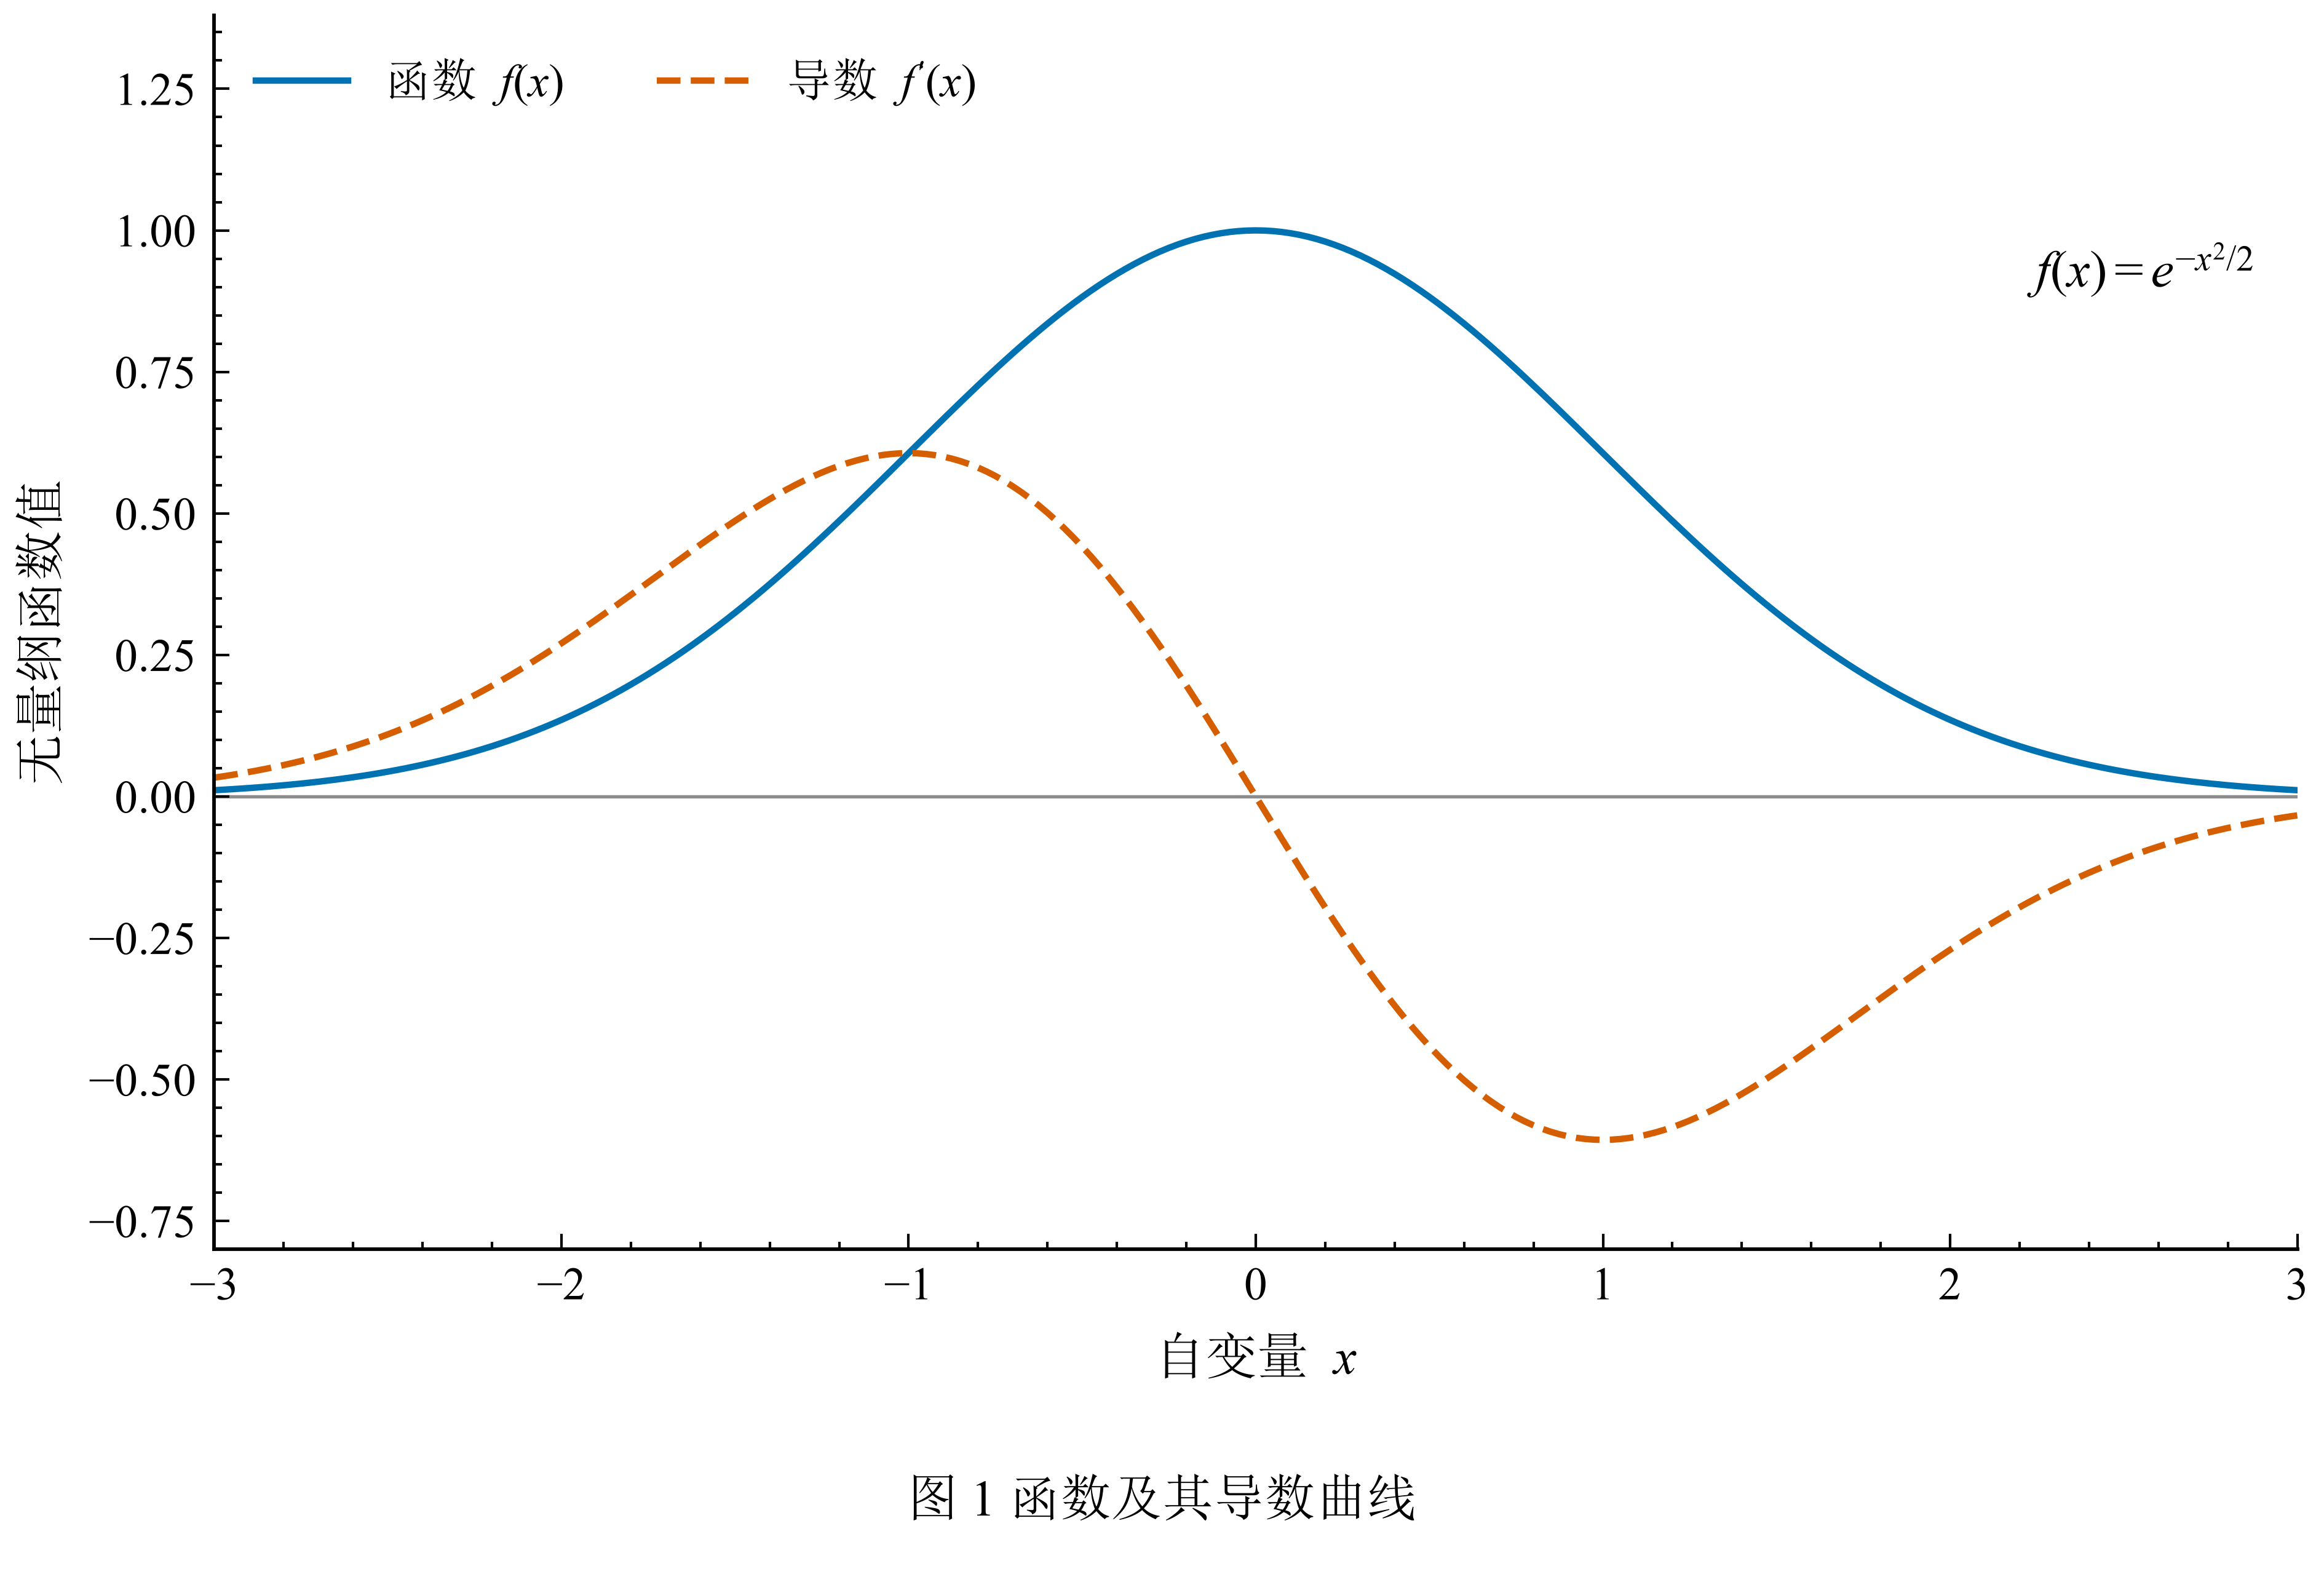

In [2]:
x = np.linspace(-3, 3, 241)  # 以固定间隔采样明确定义的无量纲区间。
f = np.exp(-x ** 2 / 2)  # 计算高斯形状函数而非拟合实验数据。
derivative = -x * f  # 按解析公式计算一阶导数。
curve_source = output / 'function_values.csv'  # 保存图 1 的确定性输入表。
np.savetxt(curve_source, np.column_stack((x, f, derivative)), delimiter=',', header='x,f,df_dx', comments='', fmt='%.12g')  # 数值与字段全部可复算。
fig1, ax1 = new_figure(width_mm=160, height_mm=108)  # 使用适合正文展示的最终物理尺寸。
ax1.plot(x, f, color='#0072B2', linestyle='-', label=r'函数 $f(x)$')  # 以蓝色实线呈现函数。
ax1.plot(x, derivative, color='#D55E00', linestyle='--', label=r'导数 $f^{\prime}(x)$')  # 以橙色虚线保证黑白打印也可区分。
ax1.axhline(0, color='0.55', linewidth=0.65, zorder=0)  # 零基准线弱于实际函数线。
ax1.set(xlabel=r'自变量 $x$', ylabel='无量纲函数值', xlim=(-3, 3), ylim=(-0.8, 1.38))  # 中文与量符号置于各自文本范围。
ax1.legend(loc='upper left', ncols=2)  # 只保留辨别曲线所需的图例。
ax1.text(0.98, 0.78, r'$f(x)=e^{-x^2/2}$', transform=ax1.transAxes, ha='right')  # 使用数学文本正确渲染指数和分式。
add_figure_title(fig1, 1, '函数及其导数曲线')  # 中文图序和图题只放在图下。
qa1 = save_png(fig1, output / 'figure_1.png', font_report, source_files=[curve_source])  # 检查实际 PNG 像素、DPI 和缺字。
display(Image(filename=str(output / 'figure_1.png'), width=820))  # 展示保存后的实际图片而非临时画布。
plt.close(fig1)  # 避免 Notebook 后端额外输出重复图像。

## 2 多子图与希腊字符

分别比较 $\sin(x),\cos(x)$ 和 $\sin(2x),\cos(2x)$。两子图共用范围与尺度；右图内用 $\alpha,\beta,\Gamma,\Delta,\sigma,\mu$、求和及积分表达式检查字形，文字说明均为中文。公式中的大运算符允许 STIX 补字。

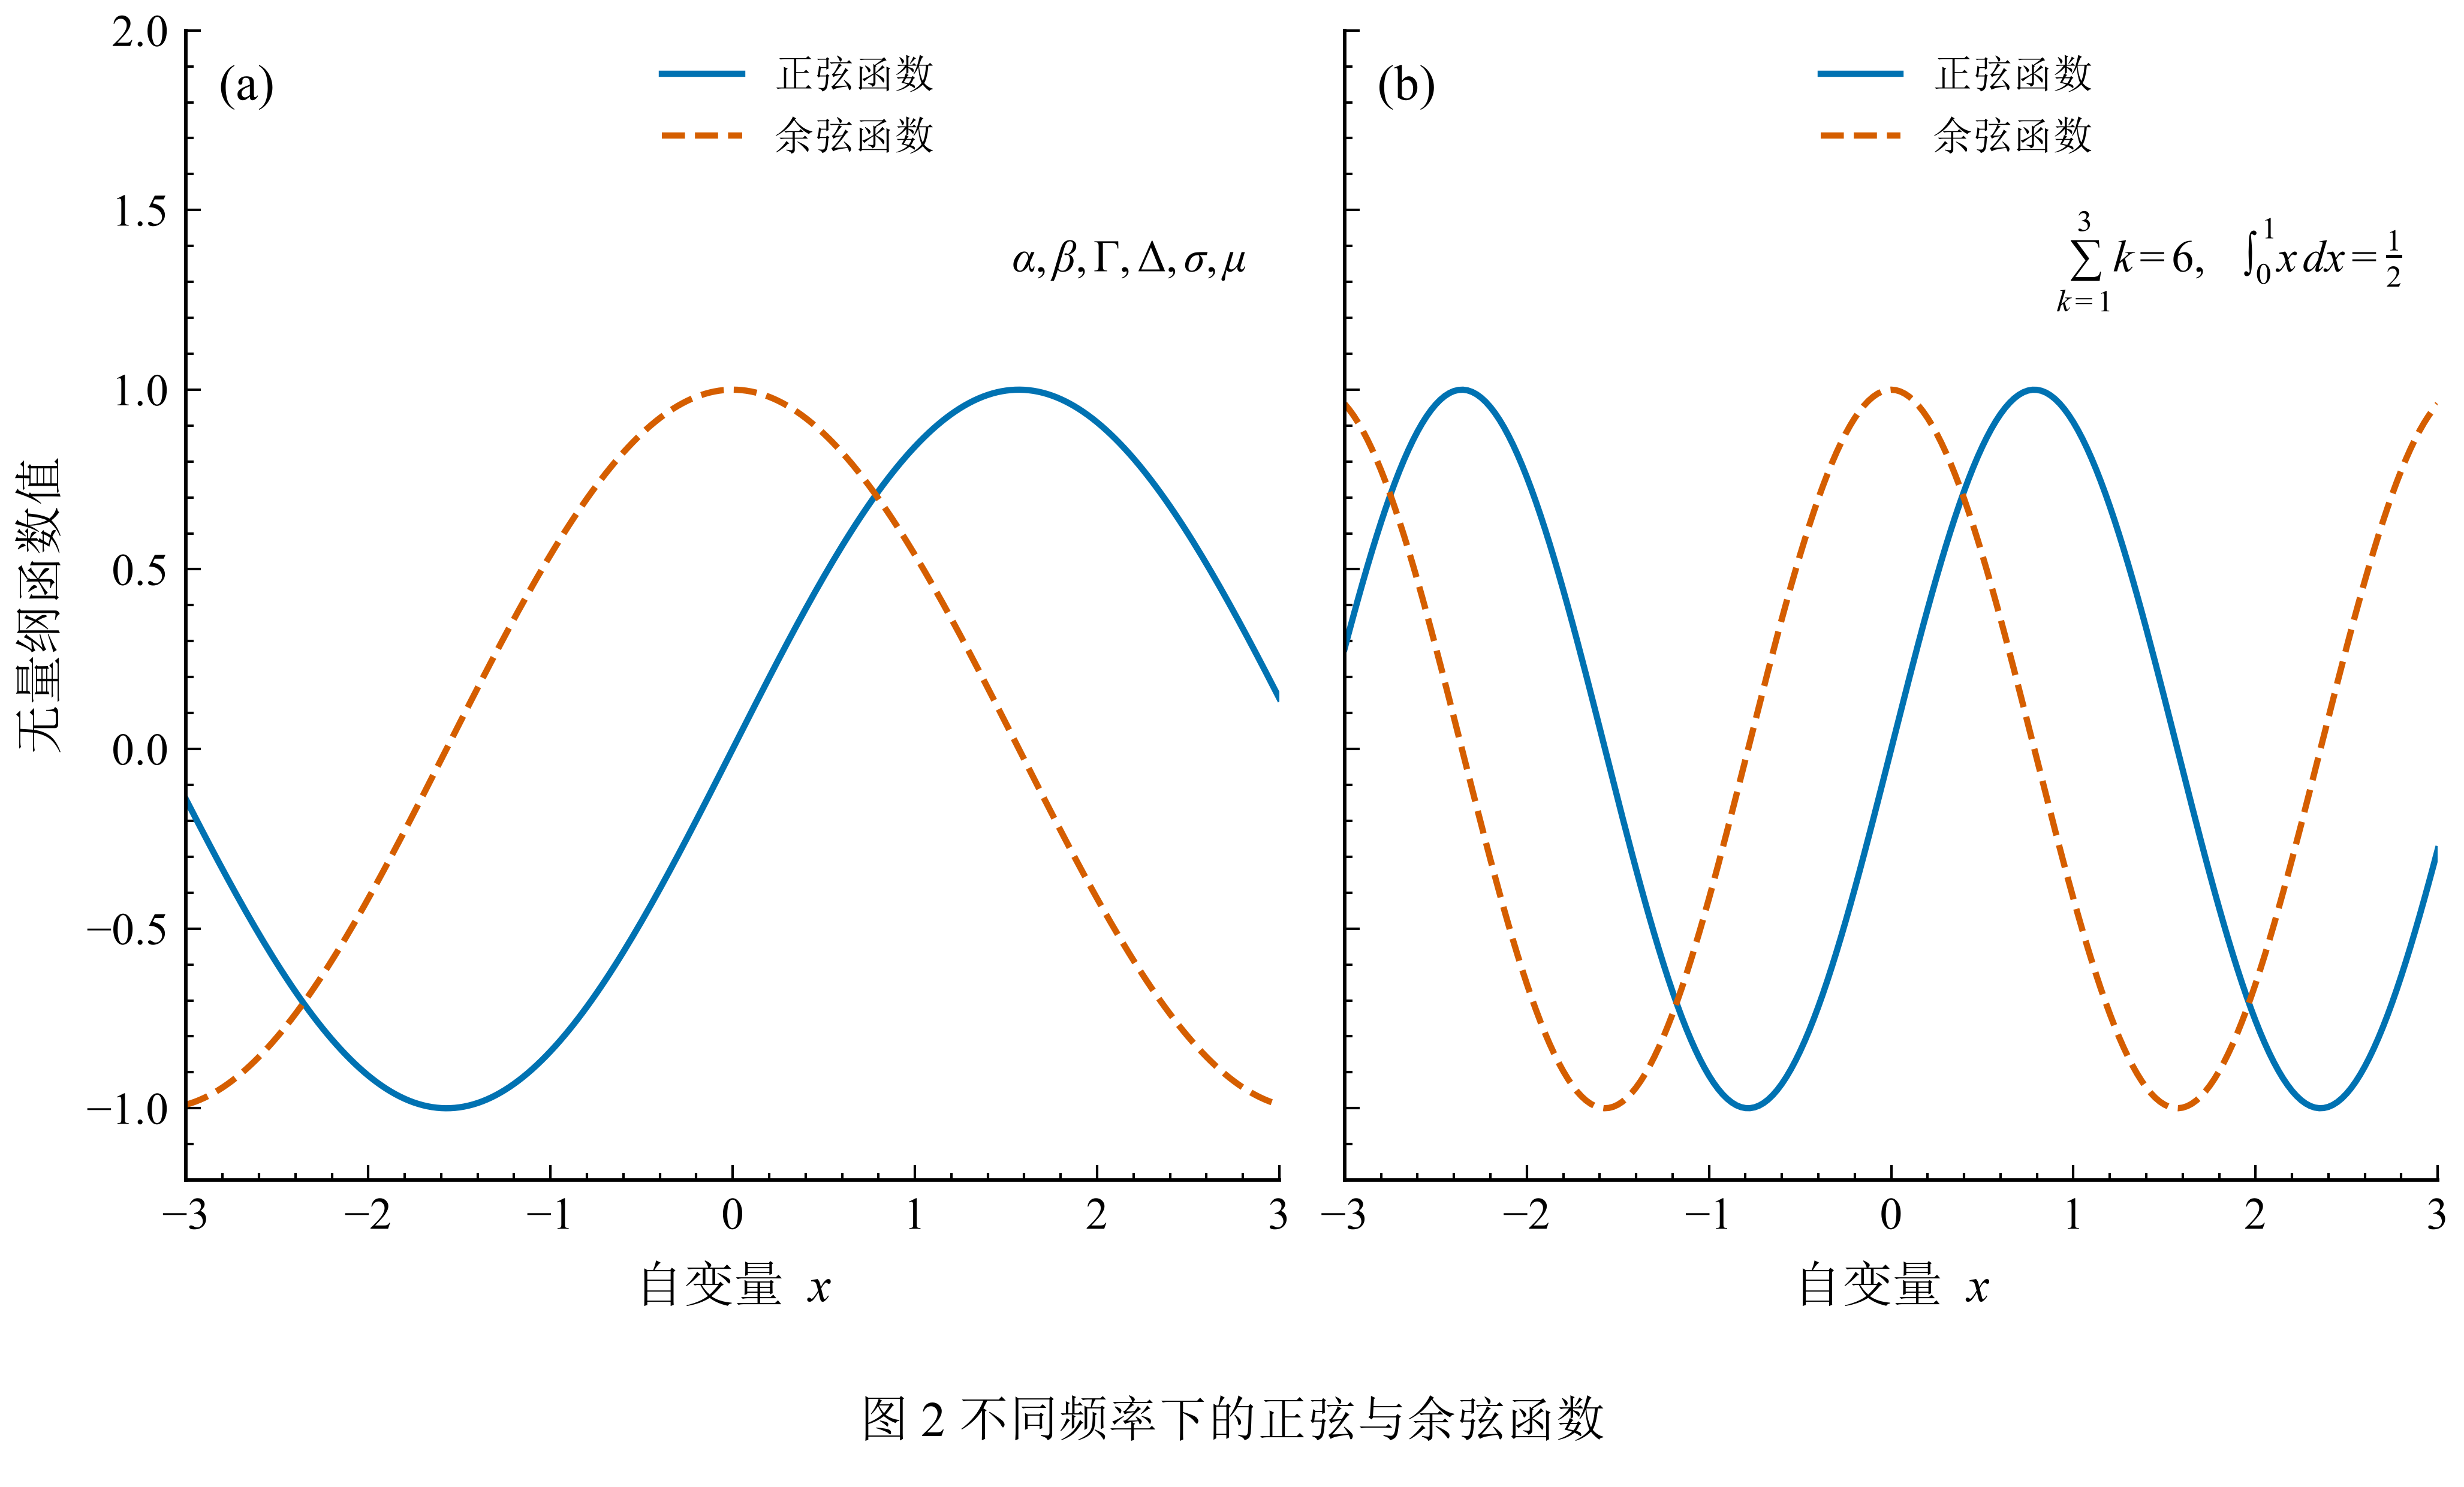

In [3]:
waves = np.column_stack((x, np.sin(x), np.cos(x), np.sin(2 * x), np.cos(2 * x)))  # 从解析定义生成四条曲线。
wave_source = output / 'wave_values.csv'  # 保存图 2 的函数值表。
np.savetxt(wave_source, waves, delimiter=',', header='x,sin_x,cos_x,sin_2x,cos_2x', comments='', fmt='%.12g')  # 记录全部绘图数值。
fig2, axes = new_figure(width_mm=174, height_mm=105, ncols=2, sharex=True, sharey=True)  # 创建上下边缘对齐的可比面板。
for index, ax in enumerate(axes):  # 使用相同的尺度、配色和线型对应关系。
    frequency = index + 1  # 两个面板分别对应角频率 1 和 2。
    ax.plot(x, np.sin(frequency * x), color='#0072B2', linestyle='-', label='正弦函数')  # 实线在所有面板中保持同一语义。
    ax.plot(x, np.cos(frequency * x), color='#D55E00', linestyle='--', label='余弦函数')  # 虚线在所有面板中保持同一语义。
    ax.set(xlabel=r'自变量 $x$', xlim=(-3, 3), ylim=(-1.2, 2.0))  # 使用共用范围并留出图例和公式区域。
    ax.text(0.03, 0.97, f'({chr(97 + index)})', transform=ax.transAxes, va='top')  # 子图标识使用新罗马字形。
    ax.legend(loc='upper center', bbox_to_anchor=(0.56, 1.01), fontsize=8)  # 避开左上角面板编号。
axes[0].set_ylabel('无量纲函数值')  # 共用纵轴无需在右侧重复占据空间。
axes[0].text(0.97, 0.79, r'$\alpha,\beta,\Gamma,\Delta,\sigma,\mu$', transform=axes[0].transAxes, ha='right', fontsize=9)  # 验证常用希腊字符。
axes[1].text(0.97, 0.79, r'$\sum_{k=1}^{3}k=6,\quad\int_0^1x\,dx=\frac{1}{2}$', transform=axes[1].transAxes, ha='right', fontsize=9)  # 验证求和、积分与分式字形。
add_figure_title(fig2, 2, '不同频率下的正弦与余弦函数')  # 全图共用一个下置中文图题。
qa2 = save_png(fig2, output / 'figure_2.png', font_report, source_files=[wave_source], alignment_groups=[list(axes)])  # 额外检查指定同排面板的边缘对齐。
display(Image(filename=str(output / 'figure_2.png'), width=860))  # 检查整幅输出的面板布局与数学字符。
plt.close(fig2)  # 释放已导出的画布。

## 3 三线表预览

下面仅检查符号排版。表内内容描述字形，不提供假造测量值。物理量名称在数学区外；量符号斜体，说明性下标 R 和单位 min 为正体。`RSD` 在本技能约定中作为量符号斜体排版，百分号为正体。其具体定义与统计口径须在真实项目正文说明。

PNG 用于预览三线结构，论文中的可编辑 Word 表格使用 `scripts/word_tables.py`；富文本表头接口及示例见 `references/three-line-tables.md`。

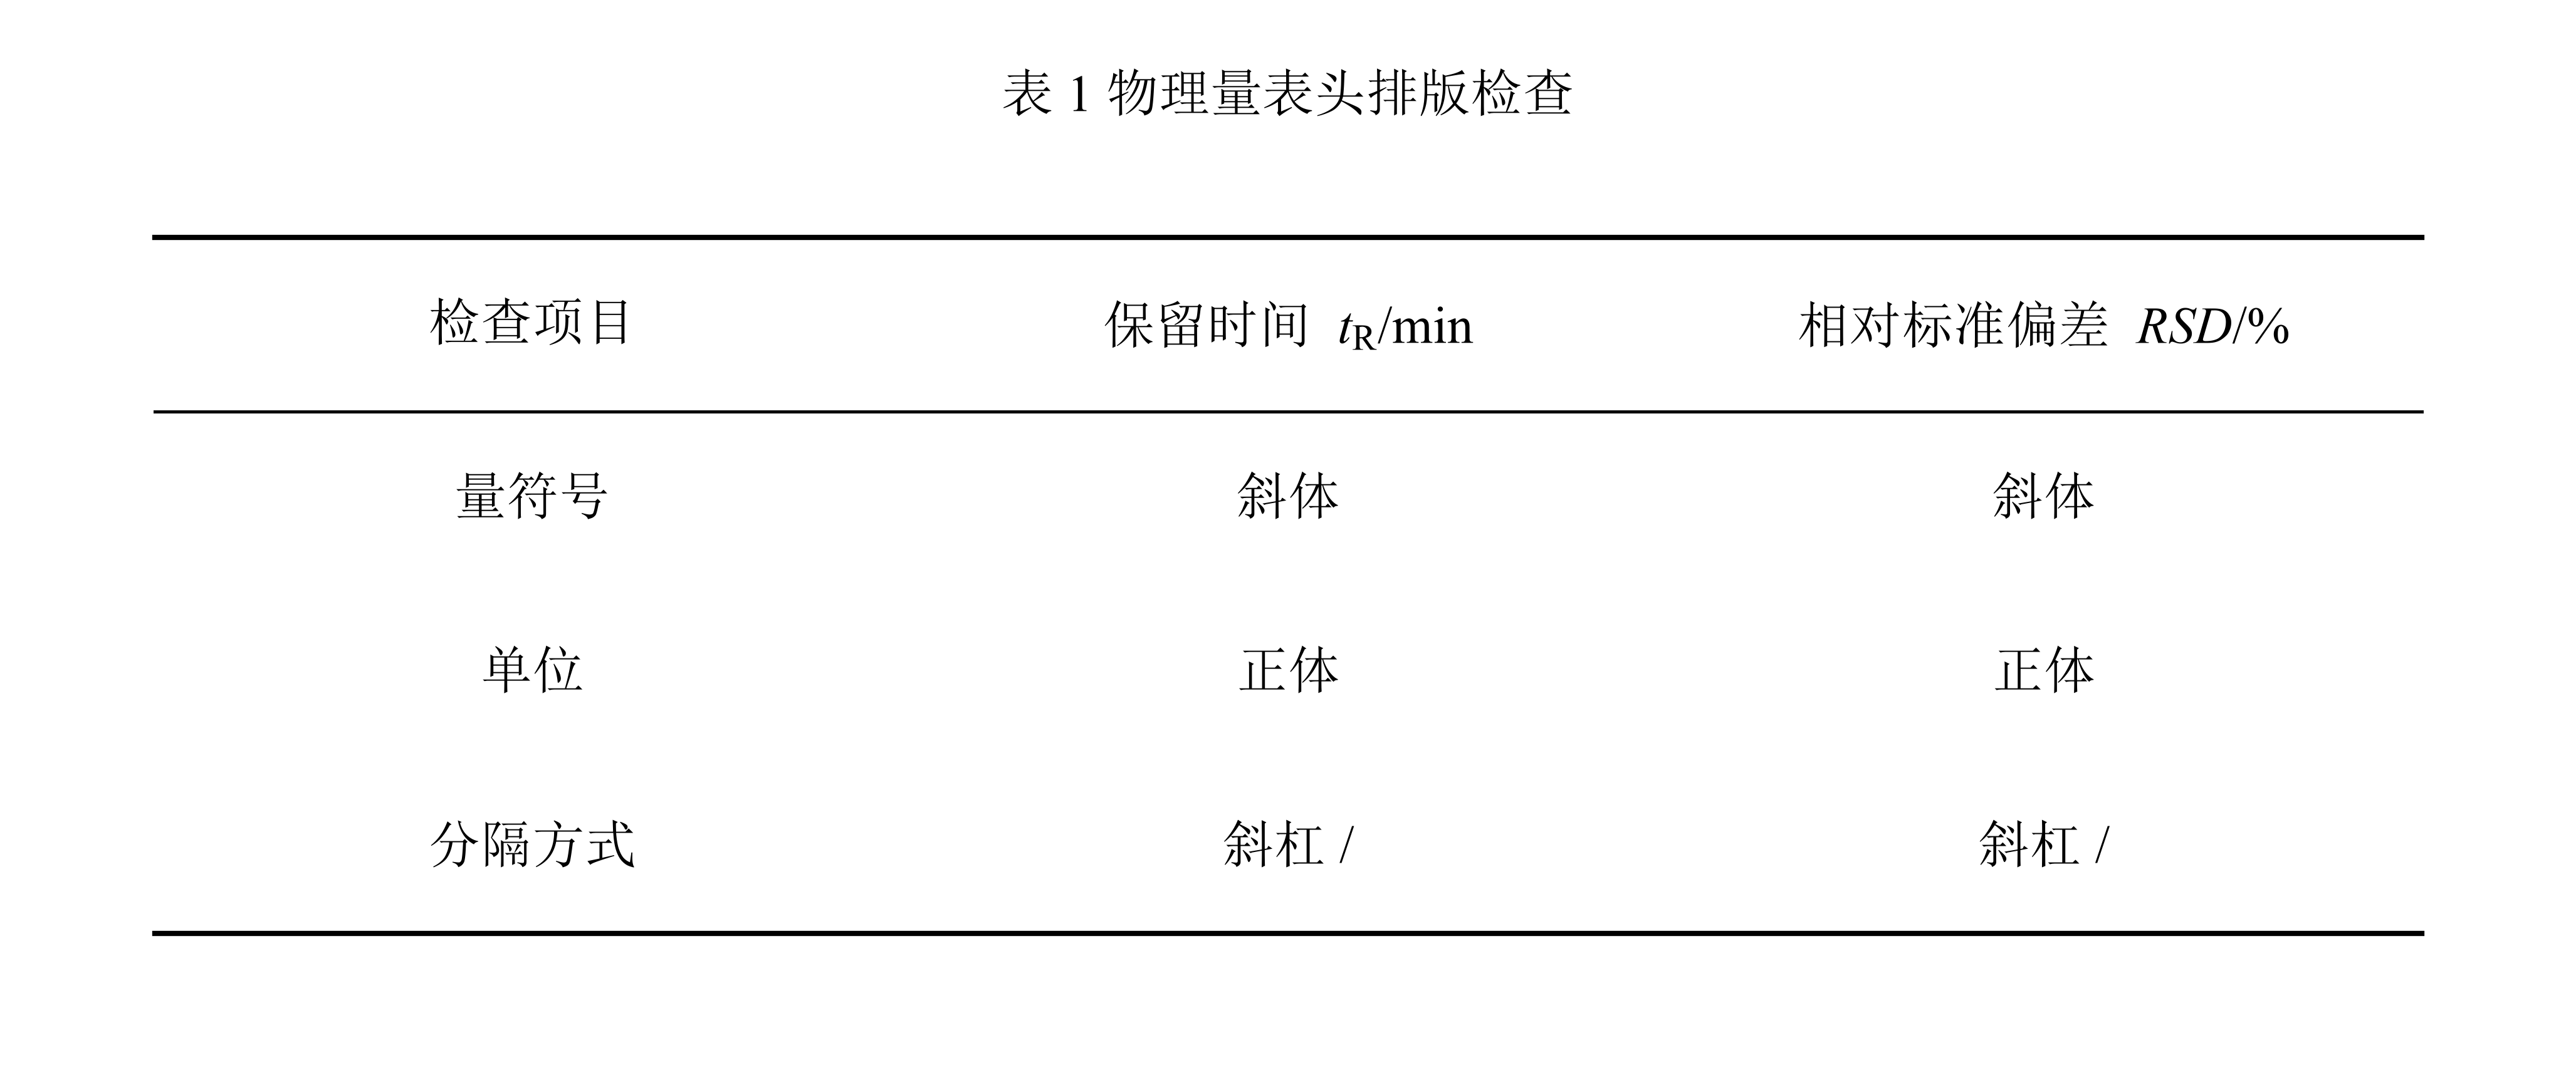

[('figure_1.png', (3779, 2551), (599.9988, 599.9988), 'PASS'), ('figure_2.png', (4110, 2480), (599.9988, 599.9988), 'PASS'), ('table_1.png', (4110, 1700), (599.9988, 599.9988), 'PASS')]


In [4]:
headers = ['检查项目', r'保留时间 $t_{\mathrm{R}}/\mathrm{min}$', r'相对标准偏差 $RSD/\%$']  # 名称、量符号与单位均出现在表头。
rows = [('量符号', '斜体', '斜体'), ('单位', '正体', '正体'), ('分隔方式', '斜杠 /', '斜杠 /')]  # 以排版规范记录替代无来源的假测量数据。
table_source = output / 'table_content.json'  # 保存三线表预览的实际文本输入。
import json  # 使用标准库保存表格内容和数学文本原式。
table_source.write_text(json.dumps({'headers': headers, 'rows': rows}, ensure_ascii=False, indent=2), encoding='utf-8')  # 为表格内容提供可检查来源。
fig3, table_axes = three_line_table(headers, rows, 1, '物理量表头排版检查', width_mm=174, height_mm=72)  # 表题上置且仅有三条横线。
qa3 = save_png(fig3, output / 'table_1.png', font_report, source_files=[table_source])  # 同样按 600 dpi 导出预览。
display(Image(filename=str(output / 'table_1.png'), width=860))  # 查看真实输出的表头、斜体和单位。
plt.close(fig3)  # 释放表格预览画布。
print([(record['file'], record['pixels'], record['dpi'], record['machine_status']) for record in (qa1, qa2, qa3)])  # 汇总机器检查，人工检查仍需完成。

## 验收与用于真实赛题

请在最终正文尺寸下检查中文缺字、数字和负号、希腊字符、上下标、图例遮线、文字重叠、三线结构以及图表题的位置。`.qa.json` 的机器通过只覆盖记录列出的检查项，不能代替人工看图。真实作图时先明确数据字段、单位、样本单位、缺失处理和误差含义；不要直接把本示例的函数或排版记录当作模型结果。改变图宽、图题、坐标标签、数据或字体后，需要重新导出与检查。